# Jupyter Notebook
# Lecture 20 - PCR



In [1]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import time

import seaborn as sns

# ML imports we've used previously
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error



# PCR on Hitters Data

# Loading in the data

Ok, here we go, let's play with a baseball data set again. Note this cleanup is all the same as previously. 

In [2]:
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/7c9ee5baa268e98bd5a1cade1809d7fe/Hitters.csv"
df = pd.read_csv(url).dropna().drop('Player', axis = 1)
df.info()
dummies = pd.get_dummies(df[['League', 'Division', 'NewLeague']])

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 1 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      263 non-null    int64  
 1   Hits       263 non-null    int64  
 2   HmRun      263 non-null    int64  
 3   Runs       263 non-null    int64  
 4   RBI        263 non-null    int64  
 5   Walks      263 non-null    int64  
 6   Years      263 non-null    int64  
 7   CAtBat     263 non-null    int64  
 8   CHits      263 non-null    int64  
 9   CHmRun     263 non-null    int64  
 10  CRuns      263 non-null    int64  
 11  CRBI       263 non-null    int64  
 12  CWalks     263 non-null    int64  
 13  League     263 non-null    object 
 14  Division   263 non-null    object 
 15  PutOuts    263 non-null    int64  
 16  Assists    263 non-null    int64  
 17  Errors     263 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  263 non-null    object 
dtypes: float64(1), 

In [3]:
y = df.Salary

# Drop the column with the independent variable (Salary), and columns for which we created dummy variables
X_ = df.drop(['Salary', 'League', 'Division', 'NewLeague'], axis = 1).astype('float64')

# Define the feature set X.
X = pd.concat([X_, dummies[['League_N', 'Division_W', 'NewLeague_N']]], axis = 1)

X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 1 to 321
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AtBat        263 non-null    float64
 1   Hits         263 non-null    float64
 2   HmRun        263 non-null    float64
 3   Runs         263 non-null    float64
 4   RBI          263 non-null    float64
 5   Walks        263 non-null    float64
 6   Years        263 non-null    float64
 7   CAtBat       263 non-null    float64
 8   CHits        263 non-null    float64
 9   CHmRun       263 non-null    float64
 10  CRuns        263 non-null    float64
 11  CRBI         263 non-null    float64
 12  CWalks       263 non-null    float64
 13  PutOuts      263 non-null    float64
 14  Assists      263 non-null    float64
 15  Errors       263 non-null    float64
 16  League_N     263 non-null    bool   
 17  Division_W   263 non-null    bool   
 18  NewLeague_N  263 non-null    bool   
dtypes: bool(3), f

# Principal Component Regression 

Ok, let's do Principal Components Regression.  `Scikit-learn` doesn't have a built in function to do PCR (aka PCA and then regression) but it's just as easy for us to do it ourselves. 

First step, let's figure out the `PCA` function.

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale #<--- this does the scaling of variables for us


In [5]:
pca = PCA()
print(X.shape)
X_PC = pca.fit_transform(scale(X))
print(X_PC.shape)

(263, 19)
(263, 19)


"But Professor, you said PCA was supposed to do dimension reduction, why is my feature output the same size?"

Glad you asked, young data scientist. The PCA command outputs all of the PCs, all the way up through $p=19$ the original number of dimensions. 

So, if I want the first three PCs, I can get them out as follows. I'll put it in a data frame just to add column labels, but you don't need to do that.

In [6]:
First3PCs = X_PC[:,:3]

pd.DataFrame(First3PCs, columns = ['Z1','Z2', 'Z3'])

,Z1,Z2,Z3
0,-0.009649,-1.870522,1.265145
1,0.411434,2.429422,-0.909193
2,3.466822,-0.825947,0.555469
3,-2.558317,0.230984,0.519642
4,1.027702,1.573537,1.331382
...,...,...,...
258,-0.331167,0.165663,0.775890
259,3.246183,0.543315,1.209150
260,-1.094609,0.751386,-0.935937
261,1.977682,2.184517,-0.282012


Now we can just do regression on the PCs like before. 

In [7]:
from sklearn.linear_model import LinearRegression

regr = LinearRegression()
regr.fit(X_PC[:,:3], y)
mean_squared_error(y,regr.predict(X_PC[:,:3]))

117234.531905816

&#9989; **<font color=red>Do this:</font>** My code above contains the rookie mistake of only reporting training error. Write modified code to return the 10-fold CV error of linear regression on the first 3 PCs.

In [8]:
# Your code here #



# You'll probably want this....
from sklearn.model_selection import cross_val_score




&#9989; **<font color=red>Do this:</font>** Take the code you figured out above to get the score for 10-fold CV on the first 3 PCs, and include it in the for-loop below to see how the MSE changes as the number of PCs you use changes. 

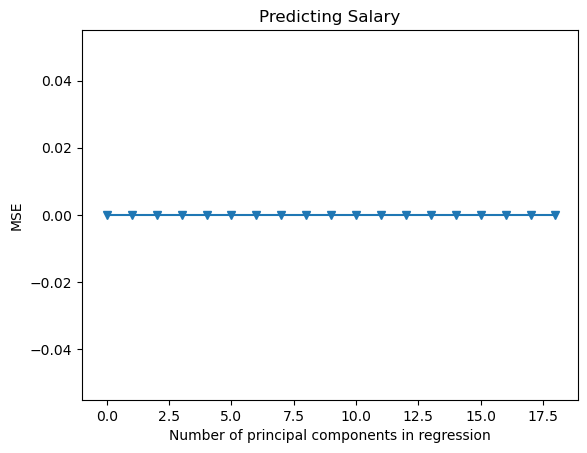

In [9]:
n = len(X_PC)
regr = LinearRegression()
mse = []

# Calculate MSE using CV for the 19 principle components, adding one component at a time.
for i in np.arange(1, 20): # i is the number of principal components to use each time
    # ====
    score = 0 # Your code from above goes here!
    # ====

    mse.append(score)
    
# Plot results    
plt.plot(mse, '-v')
plt.xlabel('Number of principal components in regression')
plt.ylabel('MSE')
plt.title('Predicting Salary')
plt.xlim(xmin=-1);

&#9989; **<font color=red>Q:</font>** Based on the graph you generated above, how many PCs do you think you should use? 

*Note: Based on graphs I generated, I can see a few different options for what I might decide to use for number of principal components. This is one of those cases where you potentially have a different answer and/or reasoning from your neighbor, so I enourage you to talk this one through with your group.*




##Your answer here##

&#9989; **<font color=red>Q:</font>** Of the models you've built so far (Ridge, Lasso, and PCR), which would you choose to use and why? 

*Note: This goes in the no-one-right-answer bucket. Go argue with your group.*




##Your answer here##



-----
### Congratulations, we're done!
Initially created by Dr. Liz Munch, modified by Dr. Lianzhang Bao, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.